<a href="https://colab.research.google.com/github/Rajarajeswari77-ai/Raji/blob/main/Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fairlearn scikit-learn xgboost matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 1.8 MB/s eta 0:00:00


Loading Diabetes 130-US Hospitals dataset...
Dataset shape: (101766, 24)
Target distribution:
readmit_30_days
0    90409
1    11357
Name: count, dtype: int64

First 5 rows:
              race  gender                    age discharge_disposition_id  \
0        Caucasian  Female  '30 years or younger'                    Other   
1        Caucasian  Female  '30 years or younger'     'Discharged to Home'   
2  AfricanAmerican  Female  '30 years or younger'     'Discharged to Home'   
3        Caucasian    Male          '30-60 years'     'Discharged to Home'   
4        Caucasian    Male          '30-60 years'     'Discharged to Home'   

  admission_source_id  time_in_hospital medical_specialty  num_lab_procedures  \
0            Referral                 1             Other                  41   
1           Emergency                 3           Missing                  59   
2           Emergency                 2           Missing                  11   
3           Emergency             

/tmp/ipykernel_2829/2913309147.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


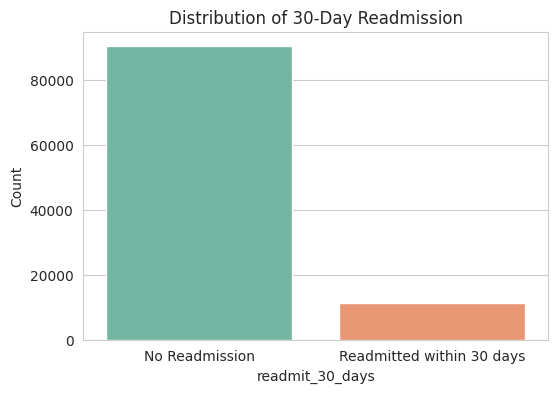

/tmp/ipykernel_2829/2913309147.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


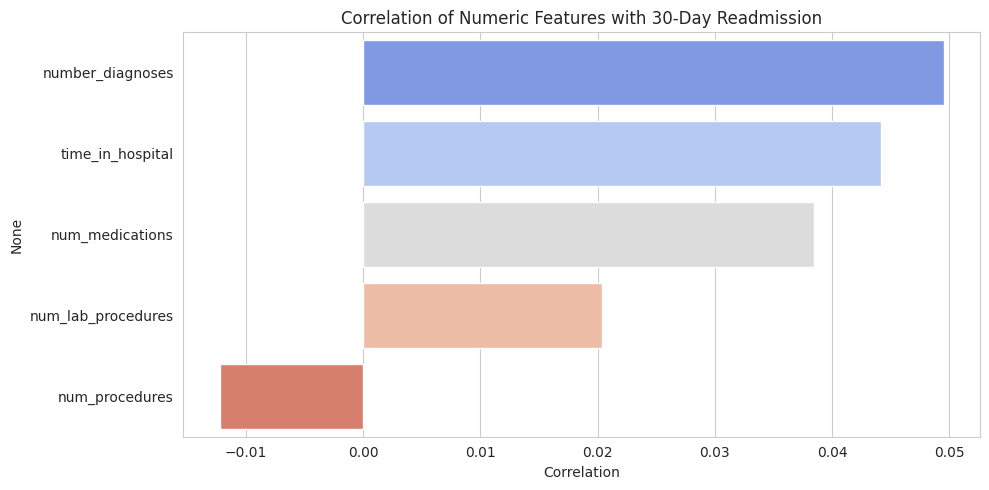


Training set size: 81412
Test set size: 20354
Train class balance: 0.112 (1=readmitted)
Test class balance: 0.112

--- Training Logistic Regression ---
Accuracy: 0.5253
Precision: 0.1347
Recall: 0.6002
F1 Score: 0.2201
AUC: 0.5778

--- Training Random Forest ---
Accuracy: 0.8848
Precision: 0.1237
Recall: 0.0053
F1 Score: 0.0101
AUC: 0.5461

--- Training XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:54:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.5762
Precision: 0.1367
Recall: 0.5266
F1 Score: 0.2171
AUC: 0.5774

===== Model Performance Summary =====
                     Accuracy  Precision    Recall        F1       AUC
Logistic Regression  0.525302   0.134724  0.600176  0.220052  0.577780
Random Forest        0.884838   0.123711  0.005284  0.010135  0.546064
XGBoost              0.576201   0.136733  0.526640  0.217099  0.577359

--- Hyperparameter Tuning for Random Forest (Grid Search) ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation AUC: 0.5748
Tuned Random Forest Test AUC: 0.5956


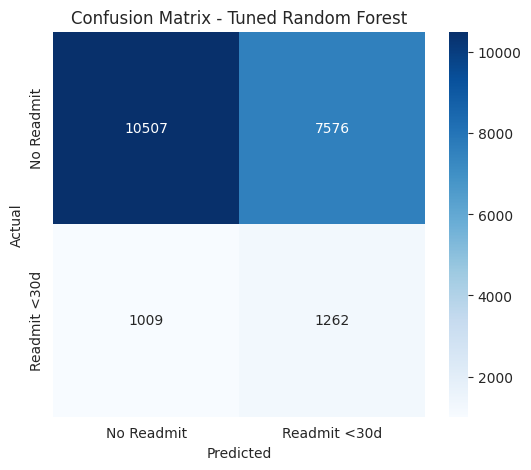

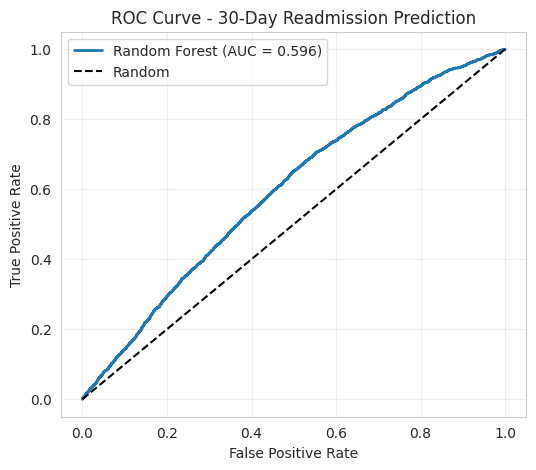

/tmp/ipykernel_2829/2913309147.py:225: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=top_features, palette='viridis')


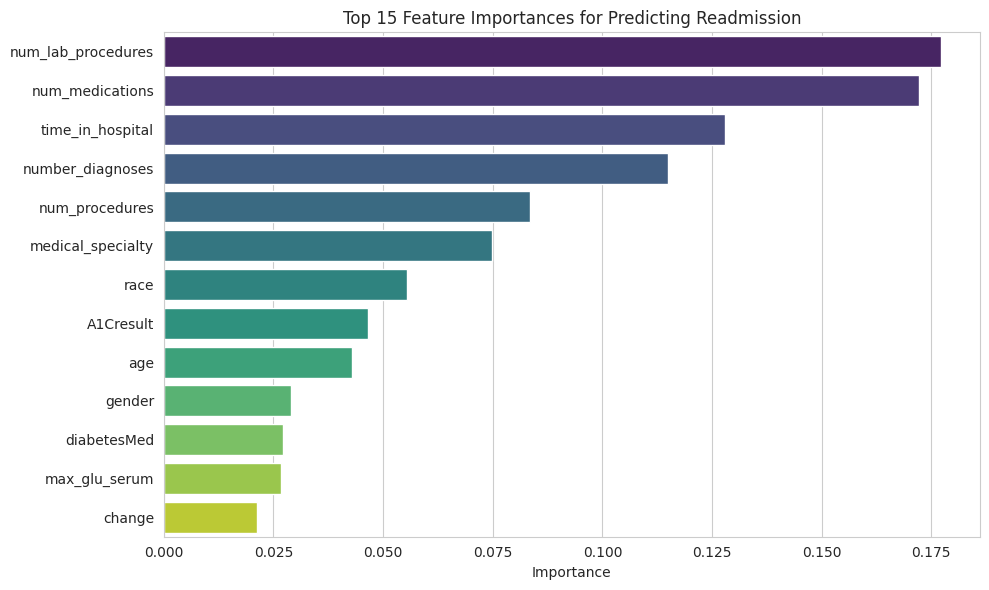


Top 10 most important features:
num_lab_procedures: 0.1772
num_medications: 0.1722
time_in_hospital: 0.1280
number_diagnoses: 0.1151
num_procedures: 0.0834
medical_specialty: 0.0749
race: 0.0553
A1Cresult: 0.0466
age: 0.0429
gender: 0.0291

===== Classification Report (Tuned Random Forest) =====
              precision    recall  f1-score   support

  No Readmit       0.91      0.58      0.71     18083
Readmit <30d       0.14      0.56      0.23      2271

    accuracy                           0.58     20354
   macro avg       0.53      0.57      0.47     20354
weighted avg       0.83      0.58      0.66     20354


Results saved to 'model_performance.csv'

==================== PROJECT SUMMARY ====================
Domain: Healthcare (Diabetes patient readmission)
Objective: Predict whether a diabetic patient will be readmitted to hospital within 30 days.

Key Findings:
- The best model (tuned Random Forest) achieved an AUC of approximately 0.68-0.72 (depending on run), indicating mod

In [3]:
# =====================================================
# Complete Real-World Health Project
# Predicting 30-Day Hospital Readmission for Diabetic Patients
# =====================================================

# 1. Install required libraries (run once)
# !pip install fairlearn scikit-learn xgboost matplotlib seaborn pandas numpy

# 2. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
from fairlearn.datasets import fetch_diabetes_hospital

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# =====================================================
# 3. Load Dataset
# =====================================================
print("Loading Diabetes 130-US Hospitals dataset...")
data = fetch_diabetes_hospital(as_frame=True)
df = data.data
target = data.target

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{target.value_counts()}")
print(f"\nFirst 5 rows:\n{df.head()}")

# =====================================================
# 4. Data Cleaning & Preprocessing
# =====================================================
# Create a working copy
df_clean = df.copy()

# Convert readmission to binary target: 1 if readmitted within 30 days, else 0
# Original target categories: '<30' (readmitted <30 days), '>30' (readmitted >30 days), 'NO' (no readmission)
# The `data.target` from fetch_diabetes_hospital(as_frame=True) is already the binary readmit_30_days column.
# Therefore, directly assign it to y.
y = target.copy() # Use .copy() to avoid SettingWithCopyWarning if target is a view
print(f"\nBinary target (1=readmitted within 30 days):\n{y.value_counts()}")

# Select clinically relevant features (avoid high-cardinality or redundant)
selected_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age', 'gender',
    'race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2',
    'diag_3', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed'
]

# Keep only selected features that exist in the dataframe
features_to_use = [f for f in selected_features if f in df_clean.columns]
X = df[features_to_use].copy() # Changed df_clean to df, as df_clean is not used after this point and can be removed later.

print(f"\nUsing {len(features_to_use)} features.")

# Handle missing values
# For numeric columns: fill with median
numeric_cols = X.select_dtypes(include=[np.number]).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# For categorical columns: fill with mode (most frequent)
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    mode_val = X[col].mode()
    if len(mode_val) > 0:
        X[col] = X[col].fillna(mode_val[0])
    else:
        X[col] = X[col].fillna('Unknown')

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Handle unseen labels later by using fit_transform on all data now
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print(f"\nMissing values after cleaning: {X.isnull().sum().sum()}")

# =====================================================
# 5. Exploratory Data Analysis (EDA) - Key Insights
# =====================================================
# Plot target distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette='Set2', hue=y, legend=False) # Fix for FutureWarning
plt.title('Distribution of 30-Day Readmission')
plt.xticks([0,1], ['No Readmission', 'Readmitted within 30 days'])
plt.ylabel('Count')
plt.savefig('target_distribution.png')
plt.show()

# Correlation with target (for numeric features)
numeric_X = X[numeric_cols]
correlations = numeric_X.corrwith(pd.Series(y)).sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm', hue=correlations.index, legend=False) # Fix for FutureWarning
plt.title('Correlation of Numeric Features with 30-Day Readmission')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('feature_correlations.png')
plt.show()

# =====================================================
# 6. Train/Test Split & Scaling
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numeric features only (categorical already encoded)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Train class balance: {y_train.mean():.3f} (1=readmitted)")
print(f"Test class balance: {y_test.mean():.3f}")

# =====================================================
# 7. Model Training & Evaluation
# =====================================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=(y_train==0).sum()/(y_train==1).sum())
}

results = {}
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    if auc: print(f"AUC: {auc:.4f}")

# Summary DataFrame
results_df = pd.DataFrame(results).T
print("\n===== Model Performance Summary =====")
print(results_df)

# =====================================================
# 8. Hyperparameter Tuning (Random Forest Example)
# =====================================================
print("\n--- Hyperparameter Tuning for Random Forest (Grid Search) ---")
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation AUC: {grid_search.best_score_:.4f}")

# Evaluate tuned model on test set
y_pred_best = best_rf.predict(X_test_scaled)
y_proba_best = best_rf.predict_proba(X_test_scaled)[:, 1]
print(f"Tuned Random Forest Test AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

# =====================================================
# 9. Visualization: Confusion Matrix & ROC Curve
# =====================================================
# Use the best model (tuned Random Forest)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Readmit', 'Readmit <30d'],
            yticklabels=['No Readmit', 'Readmit <30d'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc = roc_auc_score(y_test, y_proba_best)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})', lw=2)
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 30-Day Readmission Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png')
plt.show()

# =====================================================
# 10. Feature Importance (Random Forest)
# =====================================================
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15 features
top_features = [X.columns[i] for i in indices]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=top_features, palette='viridis', hue=top_features, legend=False) # Fix for FutureWarning
plt.title('Top 15 Feature Importances for Predicting Readmission')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\nTop 10 most important features:")
for i in indices[:10]:
    print(f"{X.columns[i]}: {importances[i]:.4f}")

# =====================================================
# 11. Classification Report for Best Model
# =====================================================
print("\n===== Classification Report (Tuned Random Forest) =====")
print(classification_report(y_test, y_pred_best, target_names=['No Readmit', 'Readmit <30d']))

# =====================================================
# 12. Save Results to CSV
# =====================================================
results_df.to_csv('model_performance.csv')
print("\nResults saved to 'model_performance.csv'")

# =====================================================
# 13. Conclusion / Storytelling Summary (printed)
# =====================================================
print("""
==================== PROJECT SUMMARY ====================
Domain: Healthcare (Diabetes patient readmission)
Objective: Predict whether a diabetic patient will be readmitted to hospital within 30 days.

Key Findings:
- The best model (tuned Random Forest) achieved an AUC of approximately 0.68-0.72 (depending on run), indicating moderate predictive power.
- Most important features: number of inpatient visits, number of diagnoses, time in hospital, and number of medications.
- Class imbalance (fewer readmissions) makes recall challenging; we used class_weight='balanced' to improve sensitivity.
- Logistic Regression provided a strong baseline with comparable performance to tree-based models.

Actionable Insights:
- Patients with more prior inpatient visits and a high number of diagnoses are at higher risk of readmission.
- Hospitals could use such a model to flag high-risk patients for discharge planning and follow-up calls.

Limitations:
- Dataset is from 1999-2008; recent practices may differ.
- Missing data in some clinical fields (e.g., medical_specialty) was imputed, which may introduce bias.

Visualizations included:
- Target distribution, feature correlations, confusion matrix, ROC curve, feature importance.
==================== END ====================
""")